In [1]:
# 1. Instalação de dependências
!pip install mlflow

# 2. Bibliotecas Padrão e Visualização
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# 3. PySpark - Sessão e Estrutura
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.sql.types import IntegerType, DoubleType

# 4. PySpark - Funções SQL (Agrupadas)
from pyspark.sql.functions import (
    col, expr, regexp_extract, current_date,
    year as spark_year, udf, isnan
)

# 5. PySpark - Feature Engineering
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler
)

# 6. PySpark - Modelos e Avaliação (Regressão e Classificação)
from pyspark.ml.regression import DecisionTreeRegressor, LinearRegression
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator

# 7. PyTorch (Deep Learning)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 8. Inicialização da SparkSession
spark = SparkSession.builder \
    .appName("PySpark-Vehicle-Pricing") \
    .getOrCreate()

In [2]:
dataframe = spark.read.csv("/content/vehicles.csv", header=True, inferSchema=True)
num_linhas = dataframe.count()
print(f"Número de linhas no DataFrame: {num_linhas}")

Número de linhas no DataFrame: 441802


In [3]:
dataframe.show(20)

+----------+--------------------+--------------------+--------------------+-----+----+------------+-----+---------+---------+----+--------+------------+------------+----+-----+----+----+-----------+---------+-----------+------+-----+----+----+------------+
|        id|                 url|              region|          region_url|price|year|manufacturer|model|condition|cylinders|fuel|odometer|title_status|transmission| VIN|drive|size|type|paint_color|image_url|description|county|state| lat|long|posting_date|
+----------+--------------------+--------------------+--------------------+-----+----+------------+-----+---------+---------+----+--------+------------+------------+----+-----+----+----+-----------+---------+-----------+------+-----+----+----+------------+
|7222695916|https://prescott....|            prescott|https://prescott....| 6000|NULL|        NULL| NULL|     NULL|     NULL|NULL|    NULL|        NULL|        NULL|NULL| NULL|NULL|NULL|       NULL|     NULL|       NULL|  NULL|  

In [4]:
# =============================================================
# CAMADA BRONZE → Registrar o CSV bruto como view temporária
# =============================================================
dataframe.createOrReplaceTempView("bronze_vehicles")

# =============================================================
# CAMADA SILVER → Limpeza com Regex + car_age + remoção de colunas
# Regra: APENAS spark.sql() — zero DataFrame API de transformação
# =============================================================
df_silver = spark.sql("""
    SELECT
        -- Limpeza numérica via Regex (remove tudo que não for dígito ou ponto)
        TRY_CAST(REGEXP_REPLACE(year,      '[^0-9]',   '') AS DOUBLE) AS year,
        TRY_CAST(REGEXP_REPLACE(price,     '[^0-9.]',  '') AS DOUBLE) AS price,
        TRY_CAST(REGEXP_REPLACE(odometer,  '[^0-9.]',  '') AS DOUBLE) AS odometer,

        -- Lat/Long preservam sinal de menos
        TRY_CAST(REGEXP_REPLACE(lat,  '[^0-9.\\-]', '') AS DOUBLE) AS lat,
        TRY_CAST(REGEXP_REPLACE(long, '[^0-9.\\-]', '') AS DOUBLE) AS long,

        -- Cálculo da idade do carro diretamente no SQL
        (YEAR(CURRENT_DATE()) - TRY_CAST(REGEXP_REPLACE(year, '[^0-9]', '') AS INT)) AS car_age,

        -- Colunas categóricas mantidas sem alteração
        region, manufacturer, model, condition,
        fuel, title_status, transmission, drive,
        type, paint_color, state

        -- Colunas REMOVIDAS (id, url, region_url, VIN, image_url,
        --                    description, county, posting_date, size)
        -- simplesmente não são selecionadas aqui

    FROM bronze_vehicles
""")

df_silver.createOrReplaceTempView("silver_vehicles")
print("[Silver] Schema após limpeza:")
df_silver.printSchema()


[Silver] Schema após limpeza:
root
 |-- year: double (nullable = true)
 |-- price: double (nullable = true)
 |-- odometer: double (nullable = true)
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)
 |-- car_age: integer (nullable = true)
 |-- region: string (nullable = true)
 |-- manufacturer: string (nullable = true)
 |-- model: string (nullable = true)
 |-- condition: string (nullable = true)
 |-- fuel: string (nullable = true)
 |-- title_status: string (nullable = true)
 |-- transmission: string (nullable = true)
 |-- drive: string (nullable = true)
 |-- type: string (nullable = true)
 |-- paint_color: string (nullable = true)
 |-- state: string (nullable = true)



In [5]:
# =============================================================
# CAMADA SILVER → FILTROS DE SANIDADE (valores impossíveis)
# =============================================================
df_no_nulls = spark.sql("""
    SELECT *
    FROM silver_vehicles
    WHERE price    IS NOT NULL
      AND year     IS NOT NULL
      AND odometer IS NOT NULL
""")

df_no_nulls.createOrReplaceTempView("silver_no_nulls")

df_sanity = spark.sql("""
    SELECT *
    FROM silver_no_nulls
    WHERE price    >= 100.0   AND price    < 1000000.0
      AND year     >  2005.0  AND year     <= 2026.0
""")

df_sanity.createOrReplaceTempView("silver_sanity")

contagem = df_sanity.count()
print(f"[Silver Sanity] Registros após filtros de sanidade: {contagem}")

# =============================================================
# CAMADA SILVER → FILTRO DE OUTLIERS (percentis p10 / p90)
# Calculamos os quantis com approxQuantile e injetamos via SQL
# =============================================================
if contagem > 0:
    for col_name in ["price", "odometer"]:
        q_low, q_high = df_sanity.approxQuantile(col_name, [0.10, 0.90], 0.05)

        # Registra os limites como uma mini-view de uma linha
        # para que o filtro seguinte seja 100% SQL
        spark.sql(f"""
            CREATE OR REPLACE TEMP VIEW limits_{col_name} AS
            SELECT {q_low} AS q_low, {q_high} AS q_high
        """)

        df_sanity = spark.sql(f"""
            SELECT s.*
            FROM silver_sanity s
            CROSS JOIN limits_{col_name} l
            WHERE s.{col_name} >= l.q_low
              AND s.{col_name} <= l.q_high
        """)

        df_sanity.createOrReplaceTempView("silver_sanity")
        print(f"[Outlier] {col_name}: {q_low:.2f} → {q_high:.2f}")

    # =============================================================
    # CAMADA GOLD → dataset limpo, pronto para Feature Engineering
    # =============================================================
    df = spark.sql("SELECT * FROM silver_sanity")
    df.createOrReplaceTempView("gold_vehicles")
    df.cache()
    print(f"[Gold] Registros finais prontos para treino: {df.count()}")
else:
    print("ERRO: O filtro de sanidade removeu todos os dados. Verifique as colunas de entrada.")
    spark.sql("SELECT * FROM silver_sanity").show(5)


[Silver Sanity] Registros após filtros de sanidade: 324278
[Outlier] price: 5000.00 → 35990.00
[Outlier] odometer: 19240.00 → 147000.00
[Gold] Registros finais prontos para treino: 186660


In [6]:
# =========================
# 3. Colunas categóricas
# =========================

# One-hot (nominais)
categorical_cols = [
    "region", "manufacturer", "fuel", "transmission",
    "drive", "type", "paint_color", "state", "title_status"
]

# StringIndexer (ordinal ou alta cardinalidade)
index_cols = ["condition", "model"]




In [7]:
# =========================
# 4. Criar stages
# =========================
stages = []

# Index + OneHot para categóricas nominais
for col_name in categorical_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )

    encoder = OneHotEncoder(
        inputCol=col_name + "_index",
        outputCol=col_name + "_onehot",
        dropLast=True
    )

    stages += [indexer, encoder]

# Apenas index para ordinal/alta cardinalidade
for col_name in index_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )

    stages.append(indexer)



In [8]:
# =========================
# 5. Pipeline
# =========================
pipeline = Pipeline(stages=stages)
model = pipeline.fit(df)
df_prepared = model.transform(df)
df_prepared.createOrReplaceTempView("cars_prepared")


In [9]:
features_sql = spark.sql("""
SELECT *
FROM cars_prepared
LIMIT 10
""")

features_sql.show()


+------+-------+--------+-------+----------+-------+------+------------+--------------------+---------+-----+------------+------------+-----+------+-----------+-----+------------+-----------------+------------------+-------------------+----------+-------------+------------------+-------------------+-----------+-------------+----------+--------------+-----------------+------------------+-----------+-----------------+------------------+-------------------+---------------+-----------+
|  year|  price|odometer|    lat|      long|car_age|region|manufacturer|               model|condition| fuel|title_status|transmission|drive|  type|paint_color|state|region_index|    region_onehot|manufacturer_index|manufacturer_onehot|fuel_index|  fuel_onehot|transmission_index|transmission_onehot|drive_index| drive_onehot|type_index|   type_onehot|paint_color_index|paint_color_onehot|state_index|     state_onehot|title_status_index|title_status_onehot|condition_index|model_index|
+------+-------+--------+-

In [10]:
df_prepared.createOrReplaceTempView("view_treino")

# Selecionamos as versões para o modelo
df_pre_treino = spark.sql("""
    SELECT
        price,
        car_age,
        odometer,
        lat,
        long,
        region_onehot,
        manufacturer_onehot,
        fuel_onehot,
        transmission_index,
        drive_onehot,
        type_onehot,
        paint_color_onehot,
        state_onehot,
        title_status_onehot,
        condition_index,
        model_index
    FROM view_treino
""")

df_pre_treino.show(10)


+-------+-------+--------+-------+----------+-----------------+-------------------+-------------+------------------+-------------+--------------+------------------+-----------------+-------------------+---------------+-----------+
|  price|car_age|odometer|    lat|      long|    region_onehot|manufacturer_onehot|  fuel_onehot|transmission_index| drive_onehot|   type_onehot|paint_color_onehot|     state_onehot|title_status_onehot|condition_index|model_index|
+-------+-------+--------+-------+----------+-----------------+-------------------+-------------+------------------+-------------+--------------+------------------+-----------------+-------------------+---------------+-----------+
|33590.0|     12| 57923.0|  32.59|    -85.48|(404,[333],[1.0])|     (38,[8],[1.0])|(5,[0],[1.0])|               1.0|    (3,[],[])|(13,[2],[1.0])|    (12,[0],[1.0])|(5801,[28],[1.0])|      (6,[0],[1.0])|            0.0|      175.0|
|22590.0|     16| 71229.0|  32.59|    -85.48|(404,[333],[1.0])|     (38,[1],

In [11]:
# Garante que a UDF para ler os vetores OneHot esteja definida
get_index = udf(lambda v: float(v.indices[0]) if len(v.indices) > 0 else -1.0, DoubleType())

# Combinação de todos os filtros em uma única operação
df_pre_treino = df_pre_treino \
    .withColumn("paint_temp_idx", get_index(col("paint_color_onehot"))) \
    .withColumn("drive_temp_idx", get_index(col("drive_onehot"))) \
    .filter(
        (~col("paint_temp_idx").isin([5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0])) &
        (~col("drive_temp_idx").isin([2.0])) &
        (~col("condition_index").isin([2.0, 3.0, 4.0, 5.0]))
    ) \
    .drop("paint_temp_idx", "drive_temp_idx")

# Opcional: Verifique o resultado
# print(f"Linhas após filtros: {df_pre_treino.count()}")

In [12]:
data_norm = []
cols = ["price", "odometer", "car_age"]

for c in cols:
    stats = spark.sql(f"""
        SELECT
            MIN({c})    AS min_val,
            MAX({c})    AS max_val,
            AVG({c})    AS mean_val,
            STDDEV({c}) AS std_val
        FROM view_treino
        WHERE {c} IS NOT NULL
    """).collect()[0]

    data_norm.append({
        "col":  c,
        "min":  stats["min_val"],
        "max":  stats["max_val"],
        "mean": stats["mean_val"],
        "std":  stats["std_val"],
    })
    print(f"{c}: min={stats['min_val']:.2f} | max={stats['max_val']:.2f} "
          f"| mean={stats['mean_val']:.2f} | std={stats['std_val']:.2f}")


price: min=5000.00 | max=35990.00 | mean=18181.73 | std=8474.82
odometer: min=19240.00 | max=147000.00 | mean=79535.61 | std=36310.55
car_age: min=4.00 | max=20.00 | mean=12.09 | std=3.32


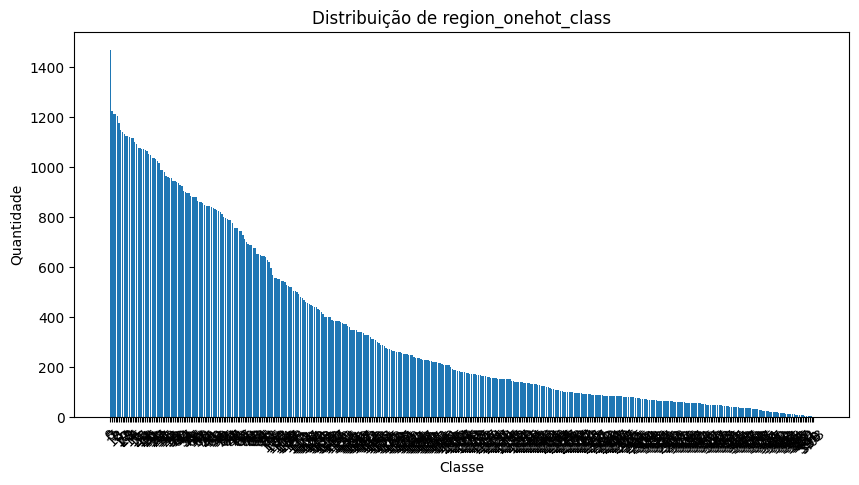

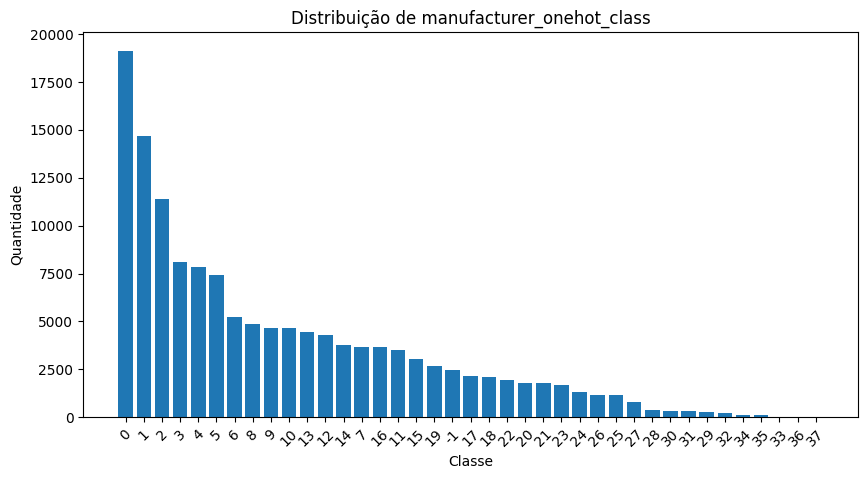

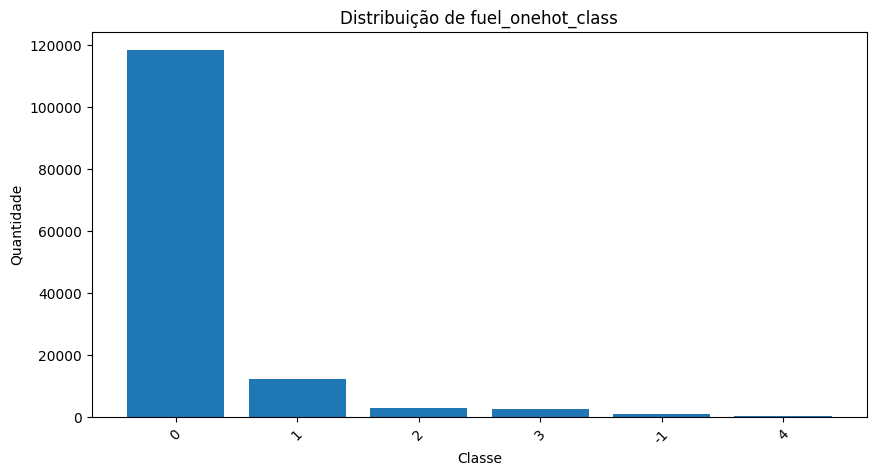

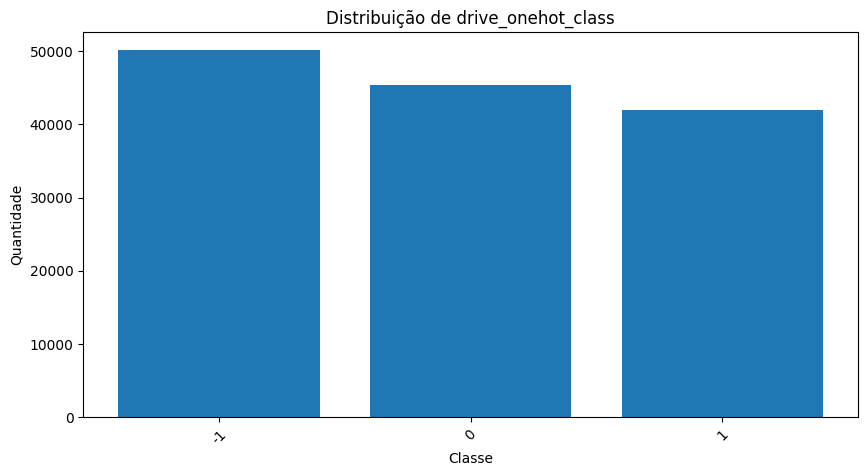

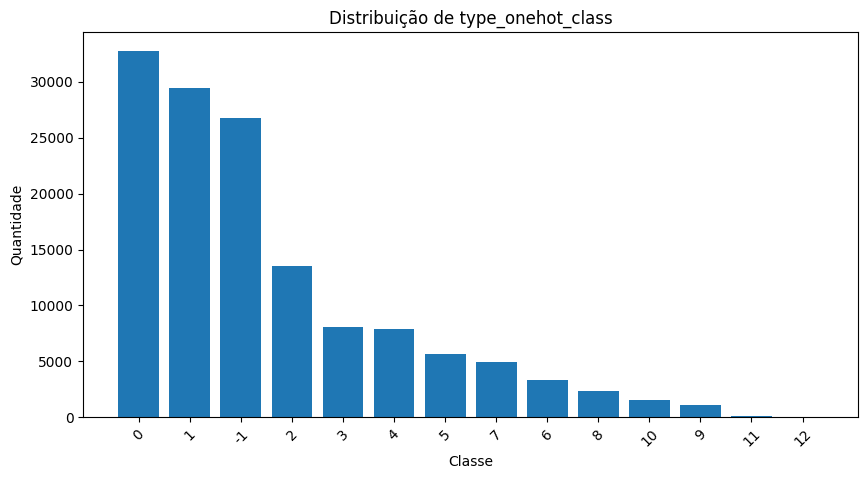

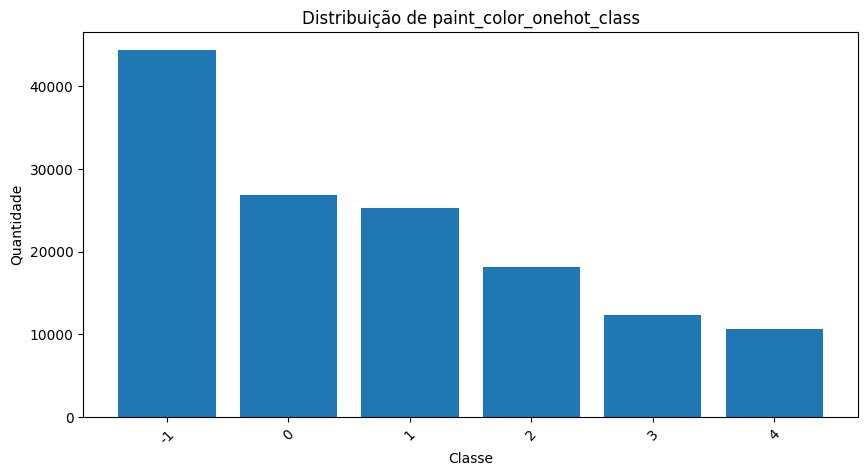

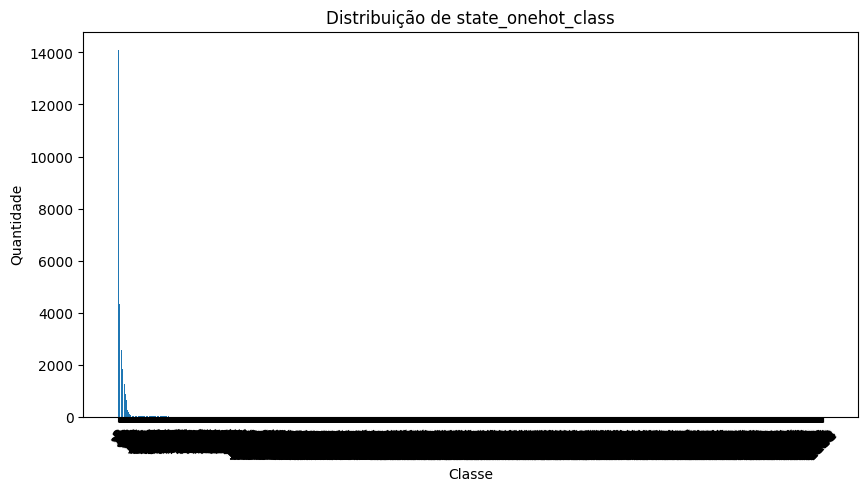

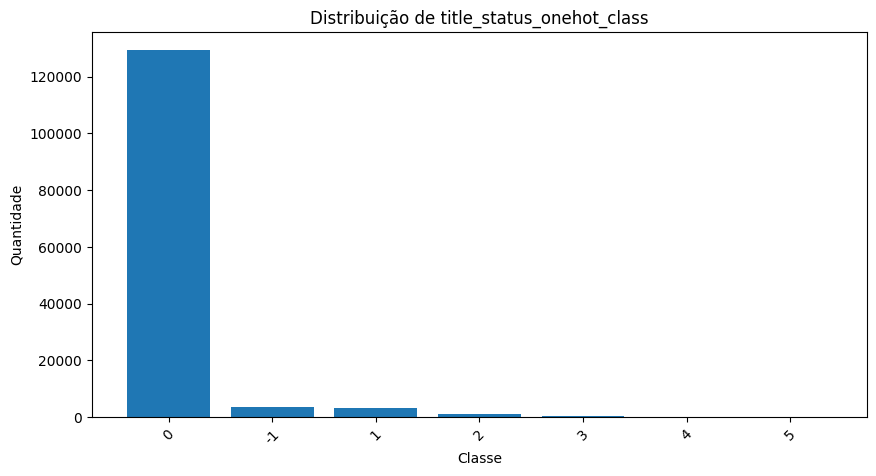

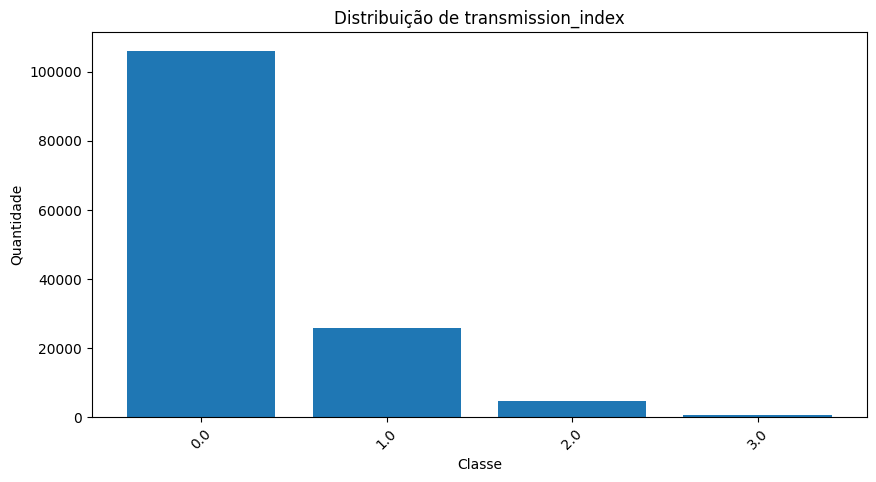

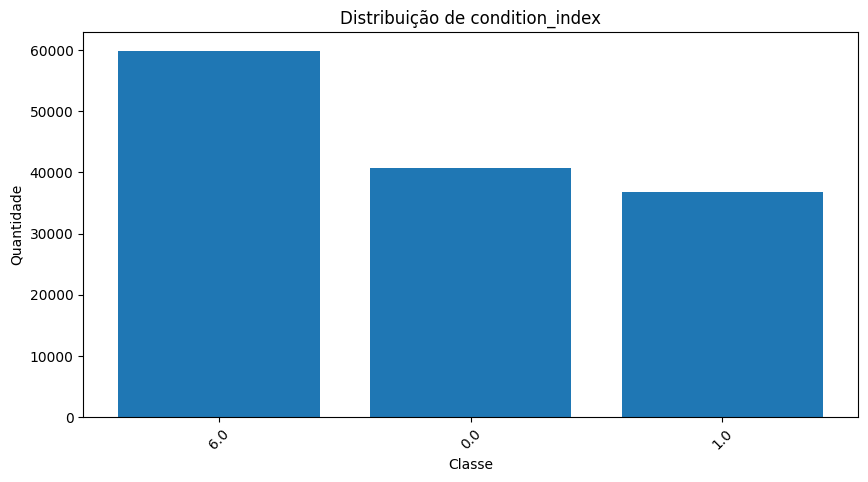

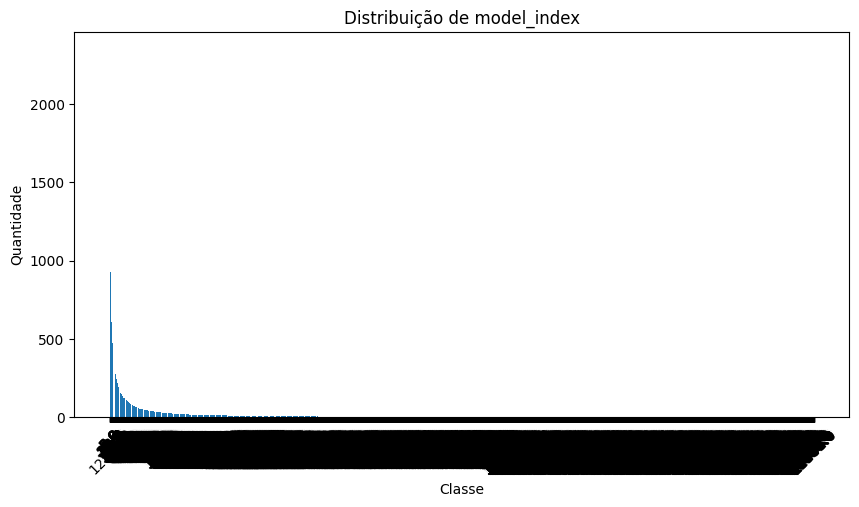

In [13]:

# Converte vetor one-hot para índice da posição ativa
def onehot_to_index(v):
    if v is None:
        return None
    arr = v.toArray()
    if arr.sum() == 0:
        return -1
    return int(arr.argmax())

onehot_to_index_udf = udf(onehot_to_index, IntegerType())

onehot_cols = [
    "region_onehot",
    "manufacturer_onehot",
    "fuel_onehot",
    "drive_onehot",
    "type_onehot",
    "paint_color_onehot",
    "state_onehot",
    "title_status_onehot"
]

index_cols = [
    "transmission_index",
    "condition_index",
    "model_index"
]

df_plot = df_pre_treino

for c in onehot_cols:
    df_plot = df_plot.withColumn(c + "_class", onehot_to_index_udf(col(c)))

plot_cols = [c + "_class" for c in onehot_cols] + index_cols

for c in plot_cols:
    data = df_plot.groupBy(c) \
        .count() \
        .orderBy("count", ascending=False) \
        .collect()

    x = [str(row[c]) for row in data]
    y = [row["count"] for row in data]

    plt.figure(figsize=(10, 5))
    plt.bar(x, y)
    plt.title(f"Distribuição de {c}")
    plt.xlabel("Classe")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45)
    plt.show()

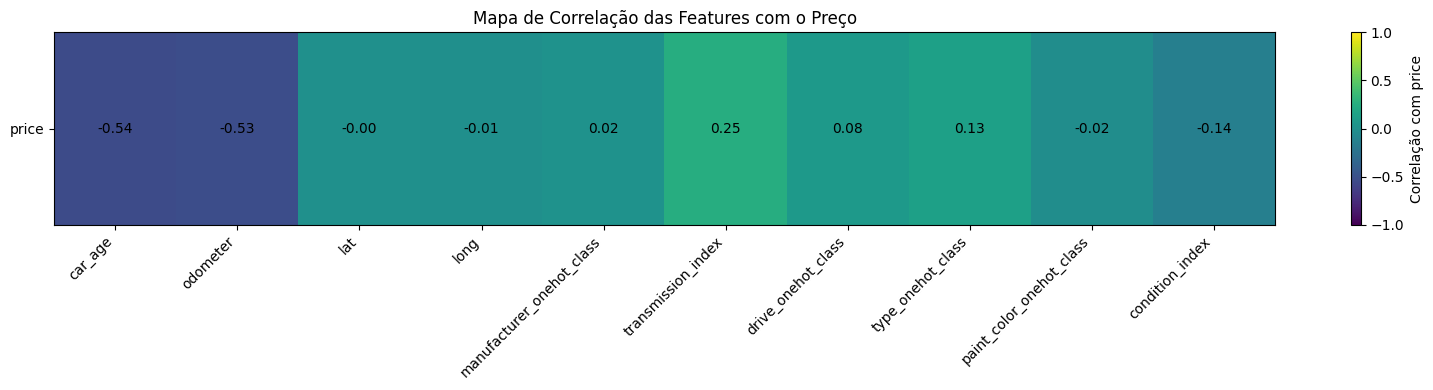

In [16]:
def onehot_to_index(v):
    if v is None:
        return None

    arr = v.toArray()

    if arr.sum() == 0:
        return -1

    return int(arr.argmax())

onehot_to_index_udf = udf(onehot_to_index, IntegerType())

df_corr = df_pre_treino

onehot_cols = [
    "manufacturer_onehot",
    "drive_onehot",
    "type_onehot",
    "paint_color_onehot"
]

for c in onehot_cols:
    df_corr = df_corr.withColumn(
        c + "_class",
        onehot_to_index_udf(col(c))
    )

corr_cols = [
    "car_age",
    "odometer",
    "lat",
    "long",
    "manufacturer_onehot_class",
    "transmission_index",
    "drive_onehot_class",
    "type_onehot_class",
    "paint_color_onehot_class",
    "condition_index"
]

cols_necessarias = ["price"] + corr_cols

df_corr = df_corr.dropna(subset=cols_necessarias)

for c in cols_necessarias:
    df_corr = df_corr.filter(~isnan(col(c)))

correlations = []

for c in corr_cols:
    corr_value = df_corr.stat.corr("price", c)

    if corr_value is None:
        corr_value = 0.0

    correlations.append(corr_value)

corr_matrix = np.array([correlations])

plt.figure(figsize=(16, 4))
plt.imshow(corr_matrix, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlação com price")

plt.xticks(
    ticks=np.arange(len(corr_cols)),
    labels=corr_cols,
    rotation=45,
    ha="right"
)

plt.yticks([0], ["price"])
plt.title("Mapa de Correlação das Features com o Preço")

for i, value in enumerate(correlations):
    plt.text(
        i,
        0,
        f"{value:.2f}",
        ha="center",
        va="center"
    )

plt.tight_layout()
plt.show()

In [17]:
df_pre_treino.count()


137458

Treinamento de Decision Tree

In [25]:
# Lista dos atributos que você definiu (Features)
feature_cols = [
    "car_age",
    "odometer",
    "transmission_index",
    "drive_onehot",
    "type_onehot",
    "condition_index"
]

# Assembler: agrupa tudo em uma coluna chamada 'features'
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Transforma o DataFrame filtrado
df_assembled = assembler.transform(df_pre_treino)
df_assembled.createOrReplaceTempView("assembled_rf")
df_model = spark.sql("SELECT features, price FROM assembled_rf")

In [26]:
# Remove as linhas que possuem null nas colunas necessárias para o treino
df_pre_treino_clean = spark.sql("""
    SELECT *
    FROM view_treino
    WHERE car_age IS NOT NULL
      AND odometer IS NOT NULL
      AND transmission_index IS NOT NULL
      AND type_onehot IS NOT NULL
      AND drive_onehot IS NOT NULL
      AND condition_index IS NOT NULL
""")

# Agora use o df_pre_treino_clean no seu transform
df_assembled_clean = assembler.transform(df_pre_treino_clean)
df_assembled_clean.createOrReplaceTempView("assembled_rf_clean")
df_model = spark.sql("SELECT features, price FROM assembled_rf_clean")

In [27]:
# 80% para treino e 20% para teste
train_data, test_data = df_model.randomSplit([0.8, 0.2], seed=42)

In [28]:
try:
    df_pre_treino.unpersist()
except:
    pass

train_data_repartitioned = train_data.repartition(8)

dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="price",
    maxDepth=13,
    seed=42
)

model = dt.fit(train_data_repartitioned)

In [22]:
# Previsões no conjunto de teste
predictions = model.transform(test_data)

# Avaliadores
evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print(f"RMSE (Erro médio): {rmse:.2f}")
print(f"R² (Precisão do modelo): {r2:.2f}")

# Mostrar as primeiras comparações entre Real e Previsto
predictions.createOrReplaceTempView("rf_preds_preview")
spark.sql("SELECT price, prediction FROM rf_preds_preview LIMIT 10").show()

RMSE (Erro médio): 4915.87
R² (Precisão do modelo): 0.66
+-------+------------------+
|  price|        prediction|
+-------+------------------+
| 6750.0|25401.093896713614|
|15400.0|19947.901801278327|
|16200.0|15550.701298701299|
| 8999.0|19947.901801278327|
| 7900.0|10555.544673539518|
|14500.0|13048.697201017812|
|13750.0|10555.544673539518|
| 6900.0|13048.697201017812|
|10499.0|14579.486891385768|
| 5900.0|11601.018912529551|
+-------+------------------+



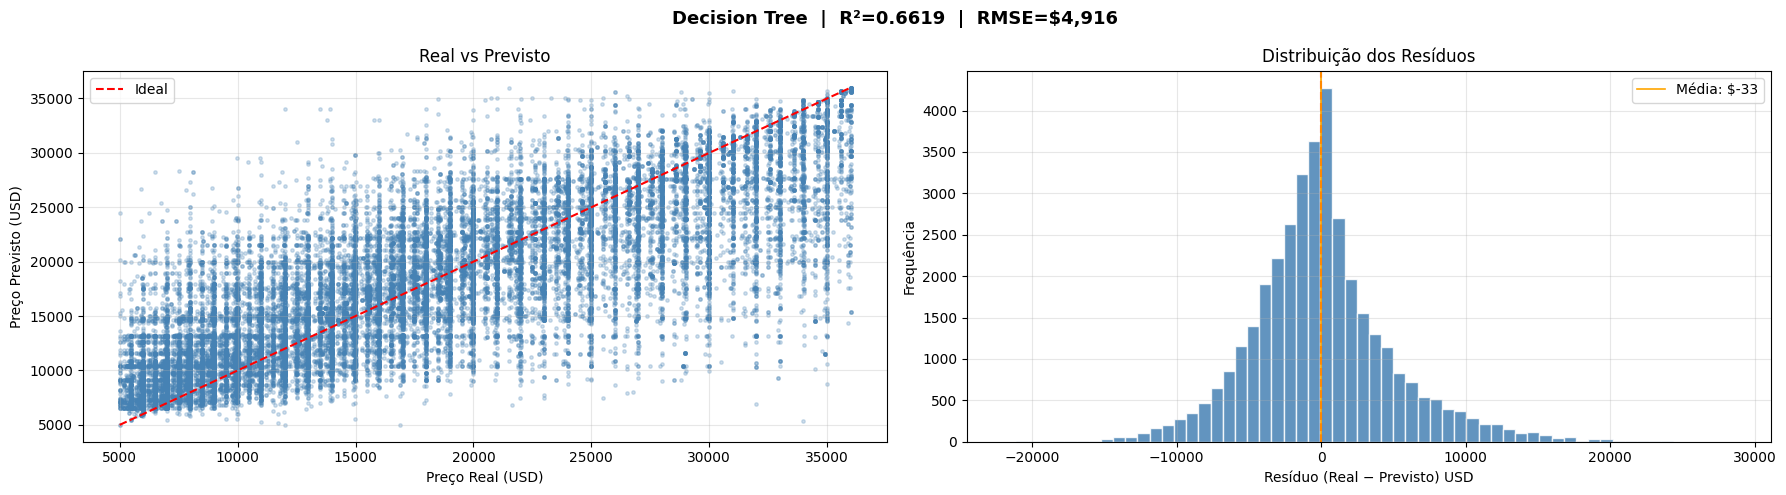

In [29]:
# ─────────────────────────────────────────────────────────────
# GRÁFICOS — Decision Tree  (100% spark.sql — sem .select/.filter)
# ─────────────────────────────────────────────────────────────

# Registra as predições como view temporária
predictions.createOrReplaceTempView("rf_predictions")

# Coleta via spark.sql — regra: toda leitura de dados via SQL
dados_rf = spark.sql("""
    SELECT
        CAST(price      AS DOUBLE) AS price_real,
        CAST(prediction AS DOUBLE) AS price_pred,
        CAST(price      AS DOUBLE) - CAST(prediction AS DOUBLE) AS residuo
    FROM rf_predictions
""").collect()

y_real_rf = np.array([float(r["price_real"]) for r in dados_rf])
y_pred_rf = np.array([float(r["price_pred"]) for r in dados_rf])
resid_rf  = np.array([float(r["residuo"])    for r in dados_rf])

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(f"Decision Tree  |  R²={r2:.4f}  |  RMSE=${rmse:,.0f}",
             fontsize=13, fontweight="bold")

# 1. Real vs Previsto
ax = axes[0]
ax.scatter(y_real_rf, y_pred_rf, alpha=0.25, s=6, color="steelblue")
lim = [min(y_real_rf.min(), y_pred_rf.min()),
       max(y_real_rf.max(), y_pred_rf.max())]
ax.plot(lim, lim, "r--", linewidth=1.5, label="Ideal")
ax.set_xlabel("Preço Real (USD)"); ax.set_ylabel("Preço Previsto (USD)")
ax.set_title("Real vs Previsto"); ax.legend(); ax.grid(True, alpha=0.3)

# 2. Distribuição dos Resíduos
ax = axes[1]
ax.hist(resid_rf, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.axvline(resid_rf.mean(), color="orange", linestyle="-",
           linewidth=1.2, label=f"Média: ${resid_rf.mean():,.0f}")
ax.set_xlabel("Resíduo (Real − Previsto) USD"); ax.set_ylabel("Frequência")
ax.set_title("Distribuição dos Resíduos"); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

Regressão Linear

In [30]:
# 1. Definimos a lista de colunas (Removendo o 'price' da lista de entrada)
feature_cols = [
    "car_age",
    "odometer",
    "region_onehot",
    "transmission_index",
    "drive_onehot",
    "type_onehot",
    "paint_color_onehot",
    "title_status_onehot",
    "condition_index",
    "model_index"
]

# 2. Criar o Assembler
# Ele vai juntar todas as colunas numéricas e os vetores OneHot em uma única coluna 'features'
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="keep" # Garante que não trave se houver algum valor nulo residual
)

# 3. Transformar os dados
df_assembled_lr = assembler.transform(df_pre_treino)
df_assembled_lr.createOrReplaceTempView("assembled_lr")
df_model = spark.sql("SELECT features, price FROM assembled_lr")

# 4. Divisão Treino e Teste (80/20)
train_data, test_data = df_model.randomSplit([0.8, 0.2], seed=42)

# 5. Configuração da Regressão Linear
# Usamos elasticNetParam=0.8 e regParam=0.1 para lidar com a alta dimensionalidade
lr = LinearRegression(
    featuresCol="features",
    labelCol="price",
    maxIter=100,
    regParam=0.1,       # Ajuda a lidar com o excesso de colunas (OneHot)
    elasticNetParam=0.8 # Combina L1 e L2 para selecionar as melhores features
)

# 6. Treinamento
lr_model = lr.fit(train_data)

# 7. Previsões e Avaliação
predictions = lr_model.transform(test_data)

evaluator_r2 = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="rmse")

r2 = evaluator_r2.evaluate(predictions)
rmse = evaluator_rmse.evaluate(predictions)

print("="*40)
print("REGRESSÃO LINEAR: LISTA COMPLETA")
print(f"R²:   {r2:.4f}")
print(f"RMSE: ${rmse:,.2f}")
print("="*40)

# Exibir comparativo real vs previsto
predictions.createOrReplaceTempView("lr_preds_preview")
spark.sql("SELECT price, prediction FROM lr_preds_preview LIMIT 10").show()

REGRESSÃO LINEAR: LISTA COMPLETA
R²:   0.6190
RMSE: $5,247.12
+-------+------------------+
|  price|        prediction|
+-------+------------------+
|21912.0|  23258.2731599556|
|24991.0|23004.828711495727|
|10194.0|13621.448020488526|
|14194.0|16706.062317816024|
| 9999.0|14263.712113133366|
| 9194.0|13498.150779752053|
|20900.0| 18195.59325729148|
|15995.0| 17341.60019619837|
|12900.0|14175.336831783181|
|12900.0|14175.336831783181|
+-------+------------------+



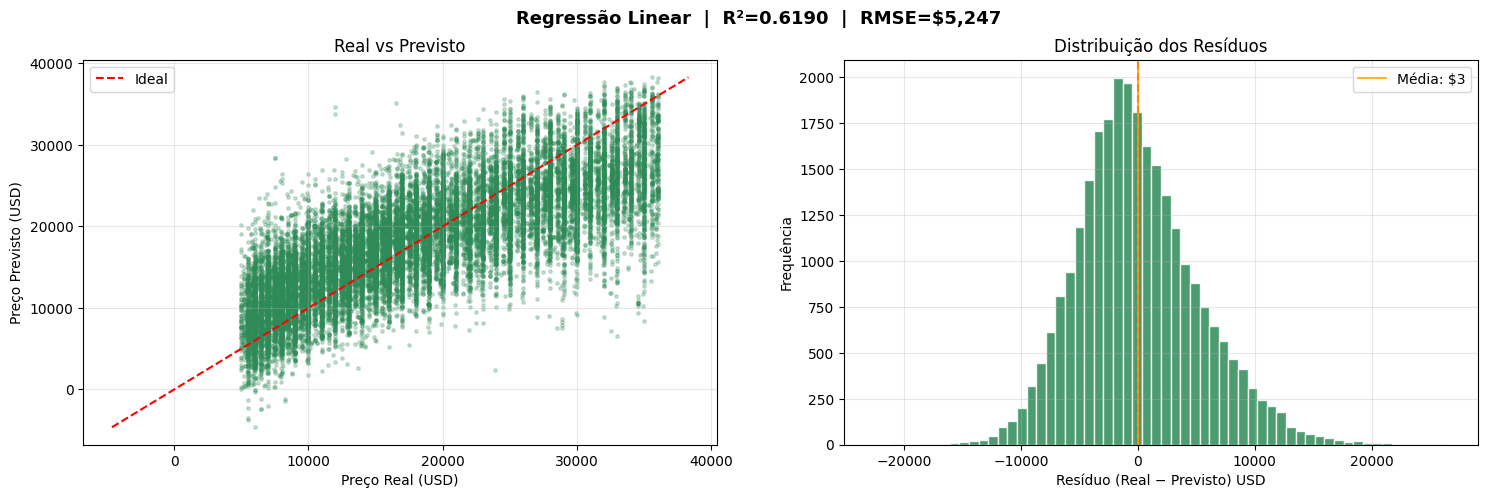

In [31]:
# ─────────────────────────────────────────────────────────────
# GRÁFICOS — Regressão Linear  (100% spark.sql — sem .select/.filter)
# ─────────────────────────────────────────────────────────────

# Registra as predições como view temporária
predictions.createOrReplaceTempView("lr_predictions")

# Coleta via spark.sql
dados_lr = spark.sql("""
    SELECT
        CAST(price      AS DOUBLE) AS price_real,
        CAST(prediction AS DOUBLE) AS price_pred,
        CAST(price      AS DOUBLE) - CAST(prediction AS DOUBLE) AS residuo
    FROM lr_predictions
""").collect()

y_real_lr = np.array([float(r["price_real"]) for r in dados_lr])
y_pred_lr = np.array([float(r["price_pred"]) for r in dados_lr])
resid_lr  = np.array([float(r["residuo"])    for r in dados_lr])

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(f"Regressão Linear  |  R²={r2:.4f}  |  RMSE=${rmse:,.0f}",
             fontsize=13, fontweight="bold")

# 1. Real vs Previsto
ax = axes[0]
ax.scatter(y_real_lr, y_pred_lr, alpha=0.25, s=6, color="seagreen")
lim = [min(y_real_lr.min(), y_pred_lr.min()),
       max(y_real_lr.max(), y_pred_lr.max())]
ax.plot(lim, lim, "r--", linewidth=1.5, label="Ideal")
ax.set_xlabel("Preço Real (USD)"); ax.set_ylabel("Preço Previsto (USD)")
ax.set_title("Real vs Previsto"); ax.legend(); ax.grid(True, alpha=0.3)

# 2. Distribuição dos Resíduos
ax = axes[1]
ax.hist(resid_lr, bins=60, color="seagreen", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.axvline(resid_lr.mean(), color="orange", linestyle="-",
           linewidth=1.2, label=f"Média: ${resid_lr.mean():,.0f}")
ax.set_xlabel("Resíduo (Real − Previsto) USD"); ax.set_ylabel("Frequência")
ax.set_title("Distribuição dos Resíduos"); ax.legend(); ax.grid(True, alpha=0.3)


Modelo de rede neural

In [32]:
# Lista de features otimizada (10 colunas base)
feature_cols = [
    "car_age",
    "odometer",
    "manufacturer_onehot",
    "transmission_index",
    "drive_onehot",
    "type_onehot",
    "paint_color_onehot",
    "title_status_onehot",
    "condition_index",
    "model_index"
]

# Assembler atualizado
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="skip" # Remove linhas com nulos automaticamente para evitar erro na Regressão Linear
)

# Criando o DataFrame para o modelo
# Usamos o dropna aqui para garantir que o PyTorch não receba NaNs
df_assembled_nn = assembler.transform(df_pre_treino)
df_assembled_nn.createOrReplaceTempView("assembled_nn")
df_model = spark.sql("SELECT features, price FROM assembled_nn WHERE features IS NOT NULL AND price IS NOT NULL")

# Verificação de segurança: Quantas colunas o vetor final tem agora?
dimensoes = len(spark.sql("SELECT features FROM assembled_nn LIMIT 1").collect()[0][0].toArray())

Iniciando treinamento no cpu...
Época 00 | Loss Treino: 0.4655 | Loss Val: 0.2860
Época 01 | Loss Treino: 0.3011 | Loss Val: 0.2689
Época 02 | Loss Treino: 0.2829 | Loss Val: 0.2593
Época 03 | Loss Treino: 0.2731 | Loss Val: 0.2515
Época 04 | Loss Treino: 0.2659 | Loss Val: 0.2469
Época 05 | Loss Treino: 0.2597 | Loss Val: 0.2445
Época 06 | Loss Treino: 0.2562 | Loss Val: 0.2414
Época 07 | Loss Treino: 0.2519 | Loss Val: 0.2359
Época 08 | Loss Treino: 0.2474 | Loss Val: 0.2342
Época 09 | Loss Treino: 0.2444 | Loss Val: 0.2307


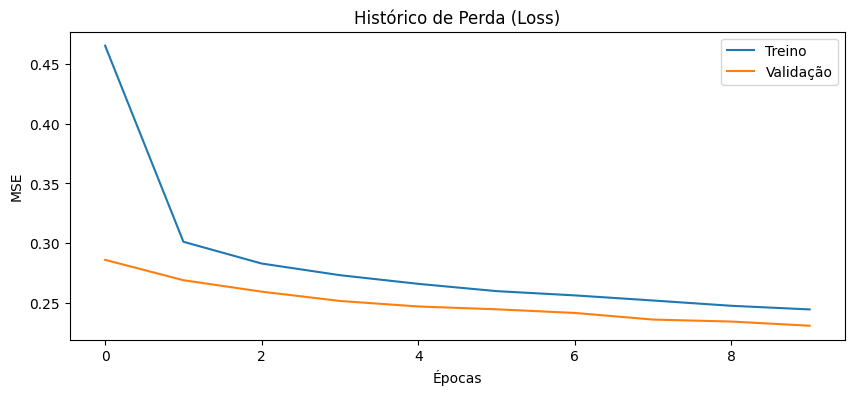


R² Score: 0.7693
RMSE: $4,086.26


In [33]:
# ============================================================
# 1. PREPARAÇÃO DAS FEATURES (LIGHTWEIGHT)
# ============================================================
from pyspark.ml.feature import VectorAssembler

# Sua lista de features otimizada
feature_cols = [
    "car_age", "odometer", "manufacturer_onehot", "transmission_index",
    "drive_onehot", "type_onehot", "paint_color_onehot",
    "title_status_onehot", "condition_index", "model_index"
]

# Configurando o Assembler
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

# Criando o DataFrame final e coletando para o Python (NumPy)
# O .dropna() aqui é vital para não quebrar a rede neural
df_assembled_nn2 = assembler.transform(df_pre_treino)
df_assembled_nn2.createOrReplaceTempView("assembled_nn2")
df_model_spark = spark.sql("SELECT features, price FROM assembled_nn2 WHERE features IS NOT NULL AND price IS NOT NULL")
dados_coletados = df_model_spark.collect()

X_raw = np.array([row["features"].toArray() for row in dados_coletados], dtype=np.float32)
y_raw = np.array([row["price"] for row in dados_coletados], dtype=np.float32).reshape(-1, 1)

# ============================================================
# 2. NORMALIZAÇÃO E DIVISÃO (TREINO/TESTE)
# ============================================================
# Normalização Z-Score
X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0)
X_std[X_std == 0] = 1.0
X_scaled = (X_raw - X_mean) / X_std

y_mean, y_std = y_raw.mean(), y_raw.std()
y_scaled = (y_raw - y_mean) / y_std

# Split 80/20
indices = np.random.permutation(len(X_scaled))
split = int(0.8 * len(X_scaled))
train_idx, test_idx = indices[:split], indices[split:]

# Preparação para o PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_scaled[train_idx])
y_train_t = torch.tensor(y_scaled[train_idx])
X_test_t = torch.tensor(X_scaled[test_idx]).to(device)
y_test_t = torch.tensor(y_scaled[test_idx]).to(device)

# DataLoader (Batch de 1024 para velocidade)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=1024, shuffle=True)

# ============================================================
# 3. DEFINIÇÃO DO MODELO (ARQUITETURA)
# ============================================================
class CarPriceNet(nn.Module):
    def __init__(self, input_dim):
        super(CarPriceNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.layers(x)

model = CarPriceNet(X_scaled.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ============================================================
# 4. LOOP DE TREINAMENTO COM HISTÓRICO DE LOSS
# ============================================================
epochs = 10
train_losses = []
val_losses = []

print(f"Iniciando treinamento no {device}...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)

    avg_train_loss = running_loss / len(train_idx)
    train_losses.append(avg_train_loss)

    # Validação (ver como a rede se sai com dados novos)
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_t)
        v_loss = criterion(val_pred, y_test_t)
        val_losses.append(v_loss.item())

    if epoch % 1 == 0:
        print(f"Época {epoch:02d} | Loss Treino: {avg_train_loss:.4f} | Loss Val: {v_loss.item():.4f}")

# ============================================================
# 5. RESULTADOS E GRÁFICOS
# ============================================================
# Plot das curvas de aprendizado
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Treino')
plt.plot(val_losses, label='Validação')
plt.title("Histórico de Perda (Loss)")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.show()

# Avaliação Final em Dólares
model.eval()
with torch.no_grad():
    preds = model(X_test_t).cpu().numpy()

y_real = (y_test_t.cpu().numpy() * y_std) + y_mean
y_pred = (preds * y_std) + y_mean

print("\n" + "="*30)
print(f"R² Score: {r2_score(y_real, y_pred):.4f}")
print(f"RMSE: ${np.sqrt(np.mean((y_real - y_pred)**2)):,.2f}")
print("="*30)

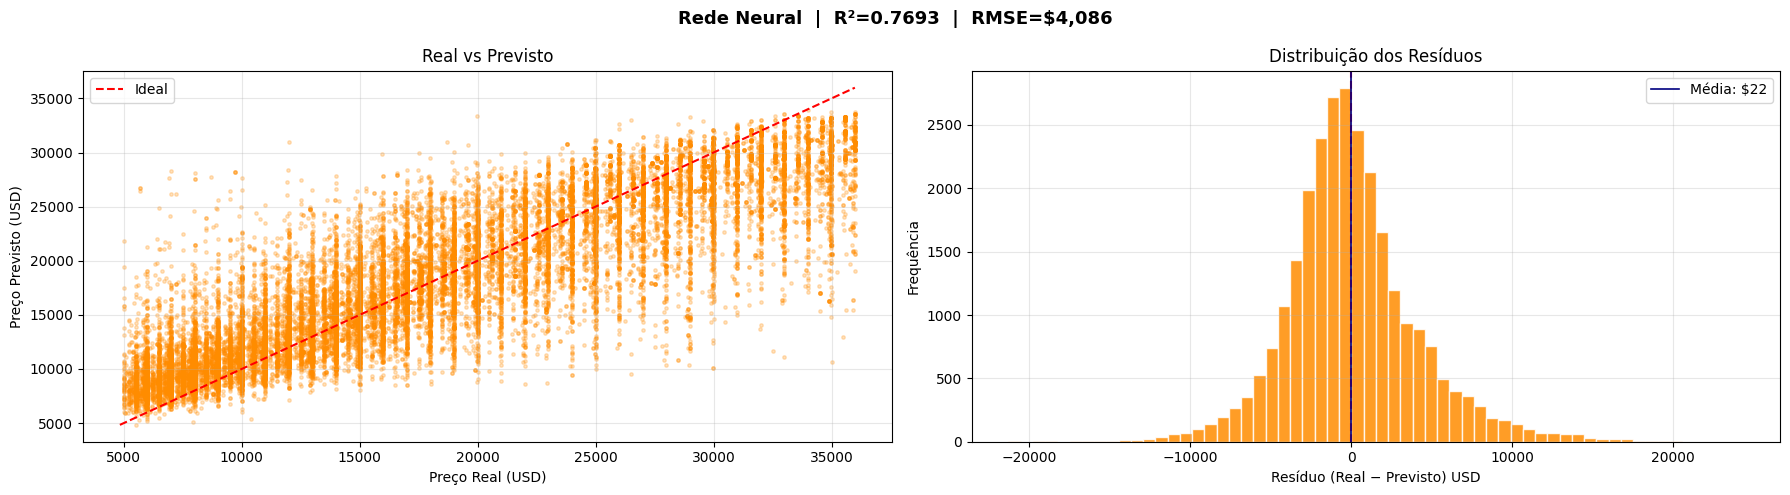

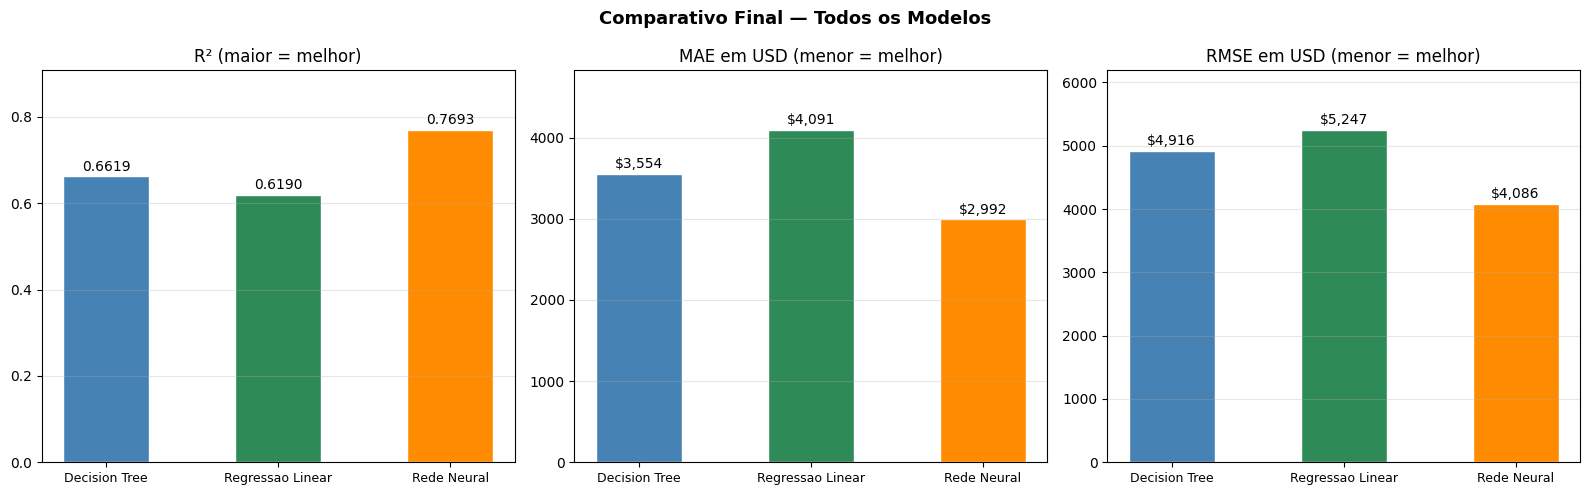

In [34]:
# ─────────────────────────────────────────────────────────────
# GRÁFICOS EXTRAS — Rede Neural
# ─────────────────────────────────────────────────────────────
y_real_flat = y_real.flatten()
y_pred_flat = y_pred.flatten()
resid_nn    = y_real_flat - y_pred_flat
r2_nn       = r2_score(y_real_flat, y_pred_flat)
rmse_nn     = float(np.sqrt(np.mean(resid_nn**2)))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(f"Rede Neural  |  R²={r2_nn:.4f}  |  RMSE=${rmse_nn:,.0f}",
             fontsize=13, fontweight="bold")

# 1. Real vs Previsto
ax = axes[0]
ax.scatter(y_real_flat, y_pred_flat, alpha=0.25, s=6, color="darkorange")
lim = [min(y_real_flat.min(), y_pred_flat.min()),
       max(y_real_flat.max(), y_pred_flat.max())]
ax.plot(lim, lim, "r--", linewidth=1.5, label="Ideal")
ax.set_xlabel("Preço Real (USD)"); ax.set_ylabel("Preço Previsto (USD)")
ax.set_title("Real vs Previsto"); ax.legend(); ax.grid(True, alpha=0.3)

# 2. Distribuição dos Resíduos
ax = axes[1]
ax.hist(resid_nn, bins=60, color="darkorange", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.axvline(resid_nn.mean(), color="navy", linestyle="-",
           linewidth=1.2, label=f"Média: ${resid_nn.mean():,.0f}")
ax.set_xlabel("Resíduo (Real − Previsto) USD"); ax.set_ylabel("Frequência")
ax.set_title("Distribuição dos Resíduos"); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


# ─────────────────────────────────────────────────────────────
# Comparativo Final — métricas dos 3 modelos via spark.sql
# ─────────────────────────────────────────────────────────────
metricas_sql = spark.sql("""
    SELECT
        'Decision Tree'                          AS modelo,
        AVG(ABS(price - prediction))             AS MAE,
        SQRT(AVG(POWER(price - prediction, 2)))  AS RMSE
    FROM rf_predictions
    UNION ALL
    SELECT
        'Regressao Linear'                       AS modelo,
        AVG(ABS(price - prediction))             AS MAE,
        SQRT(AVG(POWER(price - prediction, 2)))  AS RMSE
    FROM lr_predictions
""").collect()

mae_nn = float(np.mean(np.abs(resid_nn)))
metricas = [
    {"modelo": r["modelo"], "MAE": float(r["MAE"]), "RMSE": float(r["RMSE"])}
    for r in metricas_sql
] + [{"modelo": "Rede Neural", "MAE": mae_nn, "RMSE": rmse_nn}]

modelos_nomes = [m["modelo"] for m in metricas]
mae_vals  = [m["MAE"]  for m in metricas]
rmse_vals = [m["RMSE"] for m in metricas]
r2_vals   = [evaluator_r2.evaluate(
                 spark.sql("SELECT price, prediction FROM rf_predictions")
             ), r2, r2_nn]
colors3   = ["steelblue", "seagreen", "darkorange"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparativo Final — Todos os Modelos", fontsize=13, fontweight="bold")

for ax, vals, title, fmt in zip(
    axes,
    [r2_vals, mae_vals, rmse_vals],
    ["R² (maior = melhor)", "MAE em USD (menor = melhor)", "RMSE em USD (menor = melhor)"],
    ["{:.4f}", "${:,.0f}", "${:,.0f}"]
):
    bars = ax.bar(modelos_nomes, vals, color=colors3, edgecolor="white", width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                fmt.format(v), ha="center", va="bottom", fontsize=10)
    ax.set_title(title)
    ax.tick_params(axis="x", labelsize=9)
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_ylim(0, max(vals) * 1.18)

plt.tight_layout(); plt.show()